Starting Phase 3: CQR Conformal Prediction...
Target Confidence Level: 90.0%
Calculated CQR Adjustment (q_hat): -0.02 MW

Applying Agus I Physical Constraints...

--- TRUE TEST SET PERFORMANCE ---
Actual Validated Coverage: 91.84%


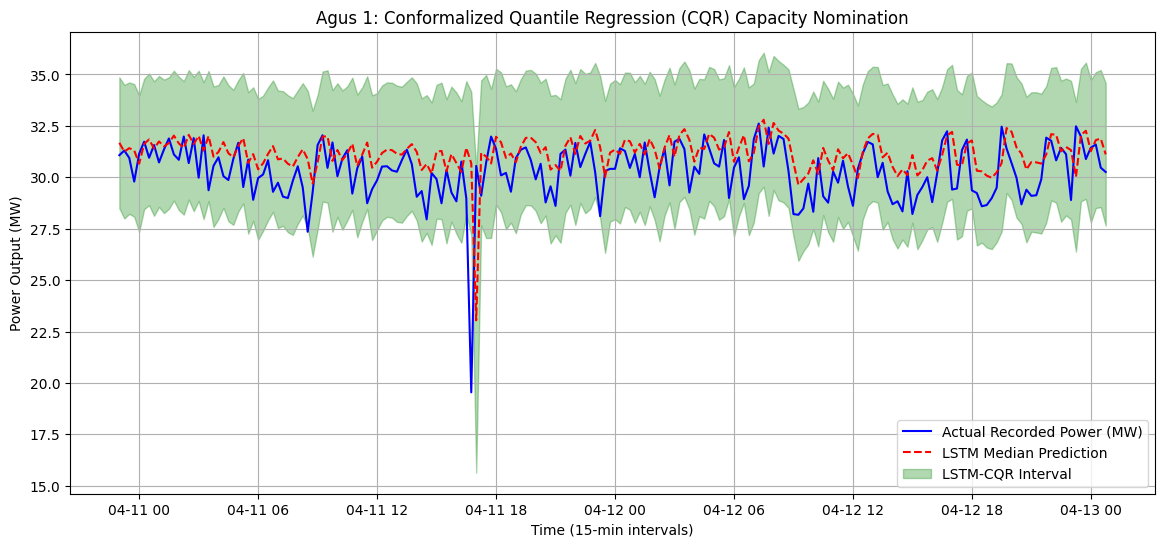

Final data exported to Agus1_Validated_CQR_Results.csv


In [8]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# 1: load raw CQR bounds and calculate median point prediction
df_calib = pd.read_csv('Agus1_CQR_Calib.csv', parse_dates=['Time'], index_col='Time')
df_test = pd.read_csv('Agus1_CQR_Test.csv', parse_dates=['Time'], index_col='Time')

n_calib = len(df_calib)
df_test['Point_Prediction_MW'] = (df_test['CQR_Lower_MW'] + df_test['CQR_Upper_MW']) / 2

# 2: execute conformal calibration to determine the rigorous interval adjustment (q_hat)
scores = np.maximum(df_calib['CQR_Lower_MW'] - df_calib['Actual_MW'], 
                    df_calib['Actual_MW'] - df_calib['CQR_Upper_MW'])

alpha = 0.10
confidence_level = 1 - alpha

q_level = math.ceil((n_calib + 1) * confidence_level) / n_calib
q_level = min(q_level, 1.0)

q_hat = np.quantile(scores.values, q_level, method='higher')

# 3: apply conformal adjustment and enforce physical constraints of Agus I
df_test['Raw_Lower_MW'] = df_test['CQR_Lower_MW'] - q_hat
df_test['Raw_Upper_MW'] = df_test['CQR_Upper_MW'] + q_hat

MAX_INSTALLED_CAPACITY_MW = 80.0  
RIPARIAN_MIN_MW = 5.04 
MIN_ELEVATION_M = 698.15 

df_test['Physics_Lower_MW'] = df_test['Raw_Lower_MW'].clip(lower=RIPARIAN_MIN_MW)
df_test['Physics_Upper_MW'] = df_test['Raw_Upper_MW'].clip(upper=MAX_INSTALLED_CAPACITY_MW)
df_test['Point_Prediction_MW'] = df_test['Point_Prediction_MW'].clip(lower=RIPARIAN_MIN_MW, upper=MAX_INSTALLED_CAPACITY_MW)

if 'Elevation' in df_test.columns:
    dead_storage_mask = df_test['Elevation'] <= MIN_ELEVATION_M
    df_test.loc[dead_storage_mask, ['Physics_Lower_MW', 'Physics_Upper_MW', 'Point_Prediction_MW']] = 0

# 4: empirically validate true coverage probability on the test set
df_test['Is_Covered'] = (df_test['Actual_MW'] >= df_test['Physics_Lower_MW']) & \
                        (df_test['Actual_MW'] <= df_test['Physics_Upper_MW'])

true_coverage = df_test['Is_Covered'].mean() * 100

# 5: visualize and export high-resolution conformal bounds and finalized data set
plt.figure(figsize=(14, 6))
subset = df_test.iloc[:200]

plt.plot(subset.index, subset['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=1.5)
plt.plot(subset.index, subset['Point_Prediction_MW'], label='LSTM Median Prediction', color='red', linestyle='dashed', linewidth=1.5)

plt.fill_between(subset.index, 
                 subset['Physics_Lower_MW'], 
                 subset['Physics_Upper_MW'], 
                 color='green', alpha=0.3, label='LSTM-CQR Interval')

plt.title('Agus 1: Conformalized Quantile Regression (CQR) Capacity Nomination')
plt.xlabel('Time (15-min intervals)')
plt.ylabel('Power Output (MW)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('Agus1_CQR_Intervals.png', dpi=500, bbox_inches='tight')
plt.show()

output_file = 'Agus1_Validated_CQR_Results.csv'
df_test.to_csv(output_file)

Plotting the entire test dataset (April to June 2025)...


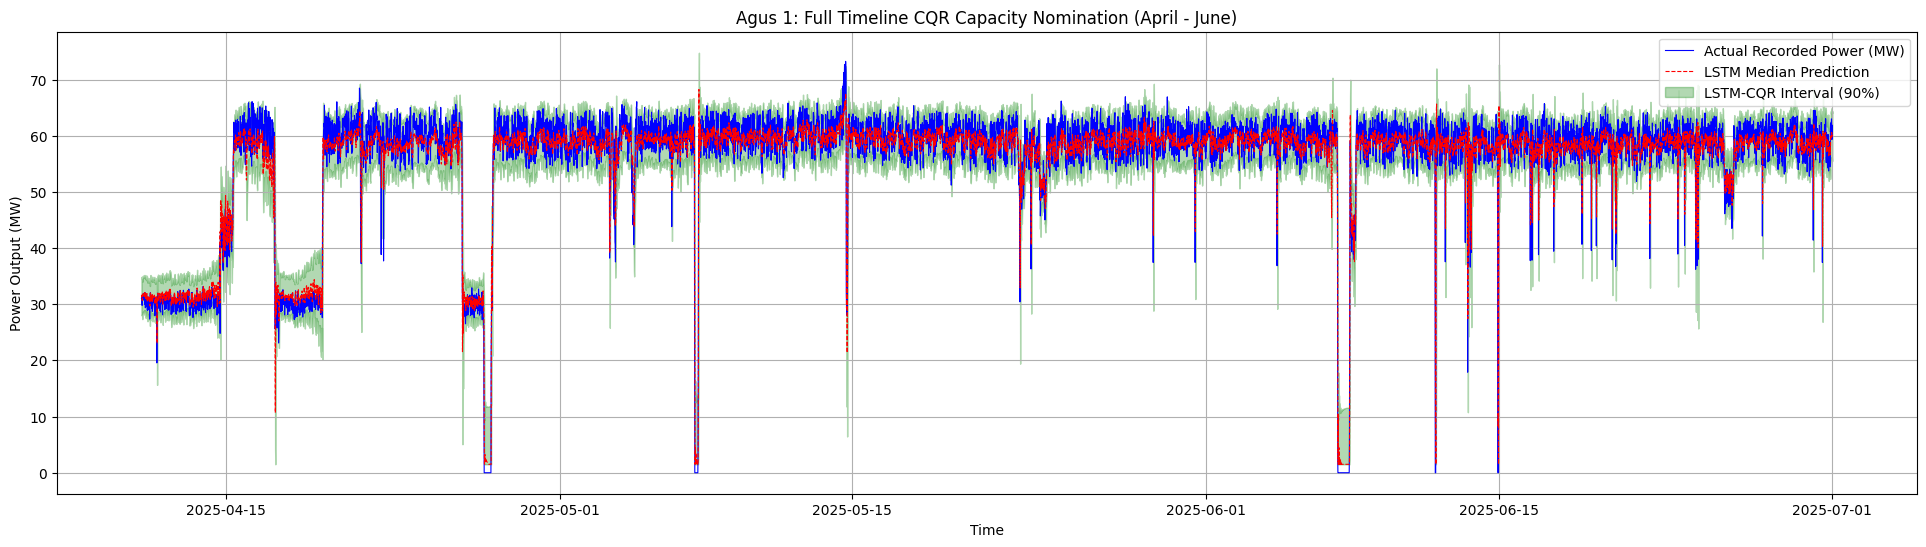

In [3]:
import matplotlib.pyplot as plt

print("Plotting the entire test dataset (April to June 2025)...")

# Increase the figure width massively so the months aren't crushed together
plt.figure(figsize=(24, 6))

# We removed the `.iloc[:200]` so it plots the whole df_test dataframe
plt.plot(df_test.index, df_test['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=0.8)
plt.plot(df_test.index, df_test['Point_Prediction_MW'], label='LSTM Median Prediction', color='red', linestyle='dashed', linewidth=0.8)

plt.fill_between(df_test.index, 
                 df_test['Physics_Lower_MW'], 
                 df_test['Physics_Upper_MW'], 
                 color='green', alpha=0.3, label='LSTM-CQR Interval (90%)')

plt.title('Agus 1: Full Timeline CQR Capacity Nomination (April - June)')
plt.xlabel('Time')
plt.ylabel('Power Output (MW)')
plt.legend(loc='upper right')
plt.grid(True)

# Save a high-resolution version for your thesis
plt.savefig('Agus1_CQR_Full_Timeline.png', dpi=900, bbox_inches='tight')
plt.show()

Generating 24-Hour Grid Event Case Study for Agus 1 (June 11, 2025)...


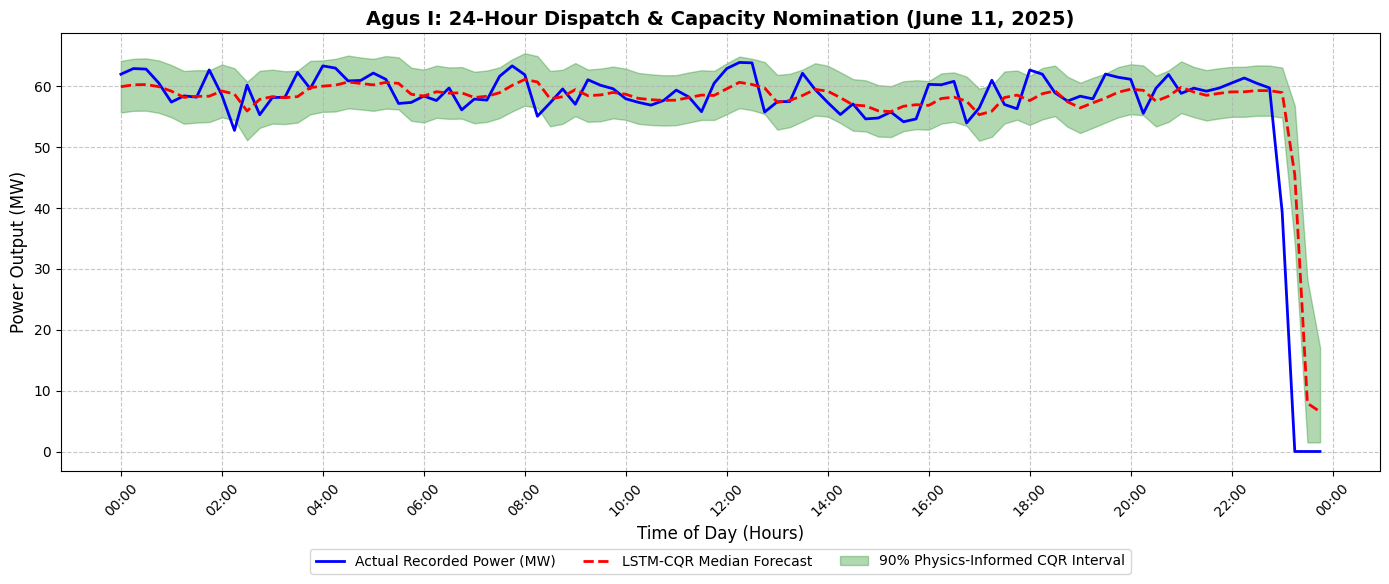

SUCCESS! Day-span plot saved.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating 24-Hour Grid Event Case Study for Agus 1 (June 11, 2025)...")

# 1. Load the Validated CQR Results from Phase 3
df_cqr = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True)

# 2. Slice the dataset for exactly June 11, 2025
day_data = df_cqr.loc['2025-06-11']

# 3. Create the Visualization
plt.figure(figsize=(14, 6))

# Plot Actual Power
plt.plot(day_data.index, day_data['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=2)

# Plot LSTM-CQR Median Prediction
plt.plot(day_data.index, day_data['Point_Prediction_MW'], label='LSTM-CQR Median Forecast', color='red', linestyle='dashed', linewidth=2)

# Fill the Physics-Informed Conformal Prediction Interval
plt.fill_between(day_data.index,
                 day_data['Physics_Lower_MW'],
                 day_data['Physics_Upper_MW'],
                 color='green', alpha=0.3, label='90% Physics-Informed CQR Interval')

# 4. Professional Academic Formatting
plt.title('Agus I: 24-Hour Dispatch & Capacity Nomination (June 11, 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day (Hours)', fontsize=12)
plt.ylabel('Power Output (MW)', fontsize=12)

# Format the x-axis to show clean hourly ticks (e.g., 08:00, 10:00)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45)

plt.legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.25))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and Show
plt.savefig('Agus1_June11_GridEvent.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Day-span plot saved.")

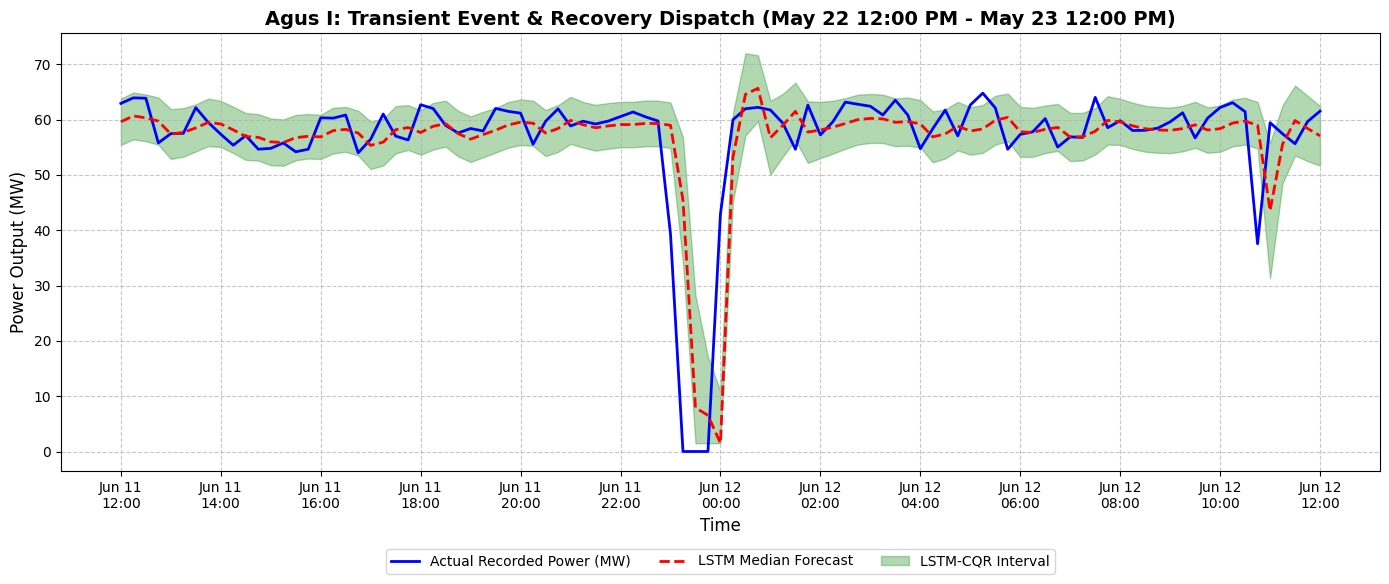

SUCCESS! Transient recovery plot saved.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Load the Validated CQR Results from Phase 3
df_cqr = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True)

# 2. Slice the dataset 
event_data = df_cqr.loc['2025-06-11 12:00:00':'2025-06-12 12:00:00']

# 3. Create the Visualization
plt.figure(figsize=(14, 6))

# Plot Actual Power
plt.plot(event_data.index, event_data['Actual_MW'], label='Actual Recorded Power (MW)', color='blue', linewidth=2)

# Plot LSTM-CQR Median Prediction
plt.plot(event_data.index, event_data['Point_Prediction_MW'], label='LSTM Median Forecast', color='red', linestyle='dashed', linewidth=2)

# Fill the Physics-Informed Conformal Prediction Interval
plt.fill_between(event_data.index,
                 event_data['Physics_Lower_MW'],
                 event_data['Physics_Upper_MW'],
                 color='green', alpha=0.3, label='LSTM-CQR Interval')

# 4. Professional Academic Formatting
plt.title('Agus I: Transient Event & Recovery Dispatch (May 22 12:00 PM - May 23 12:00 PM)', fontsize=14, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Power Output (MW)', fontsize=12)

# Format the x-axis to show BOTH the date and time since it crosses midnight
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))

plt.legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.25))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and Show
plt.savefig('Agus1_May22_23_RecoveryEvent.png', dpi=500, bbox_inches='tight')
plt.show()

print("SUCCESS! Transient recovery plot saved.")

Generating Daily Percent Error Bar Chart for Agus 1...


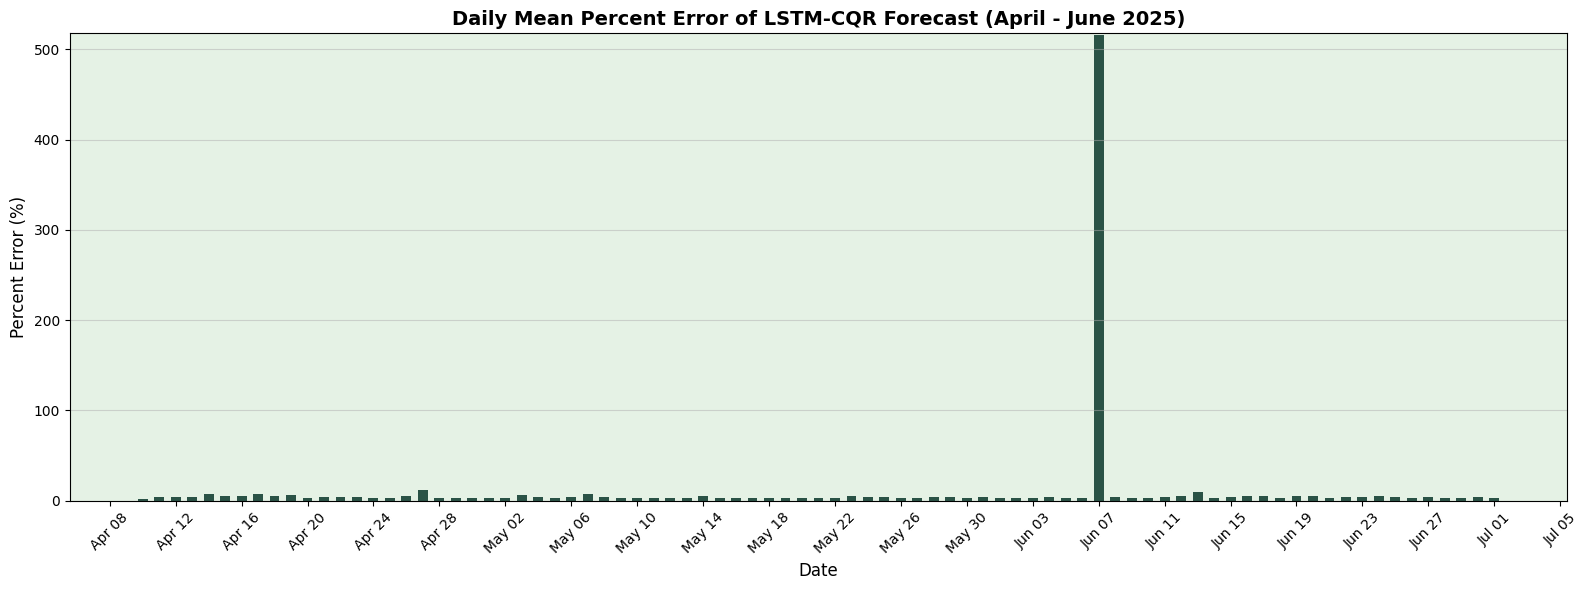

SUCCESS! Percent error bar chart saved.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Daily Percent Error Bar Chart for Agus 1...")

# 1. Load the Validated CQR Results from Phase 3
df_cqr = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True)

# 2. Calculate the Absolute Percent Error for every 15-minute step
# Note: We replace actual values of 0 with NaN temporarily to avoid "Division by Zero" math crash when the plant is off
actuals_safe = df_cqr['Actual_MW'].replace(0, np.nan)
df_cqr['Percent_Error'] = (abs(df_cqr['Actual_MW'] - df_cqr['Point_Prediction_MW']) / actuals_safe) * 100

# 3. Aggregate into Daily Averages
# This groups all 96 intervals of a day together and finds the mean percent error for that day
daily_error = df_cqr['Percent_Error'].resample('D').mean()

# 4. Create the Bar Chart Visualization
plt.figure(figsize=(16, 6))

# Plotting the bars (using a dark slate color similar to your reference book)
plt.bar(daily_error.index, daily_error.values, color='#2F4F4F', width=0.6)

# Create the subtle green background spanning across the plot area (like the reference image)
plt.axhspan(0, daily_error.max() + 2, facecolor='green', alpha=0.1)

# 5. Professional Academic Formatting
plt.title('Daily Mean Percent Error of LSTM-CQR Forecast (April - June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percent Error (%)', fontsize=12)

# Format x-axis to show the days neatly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4)) # Show every 4th day to prevent crowding
plt.xticks(rotation=45)

# Set y-axis limits to start exactly at 0
plt.ylim(0, daily_error.max() + 2)
plt.grid(axis='y', linestyle='-', alpha=0.5)

plt.tight_layout()

# Save and Show
plt.savefig('Agus1_Daily_Percent_Error.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Percent error bar chart saved.")

Generating Daily Percent Error Bar Chart for Agus 1 (Excluding June 7)...


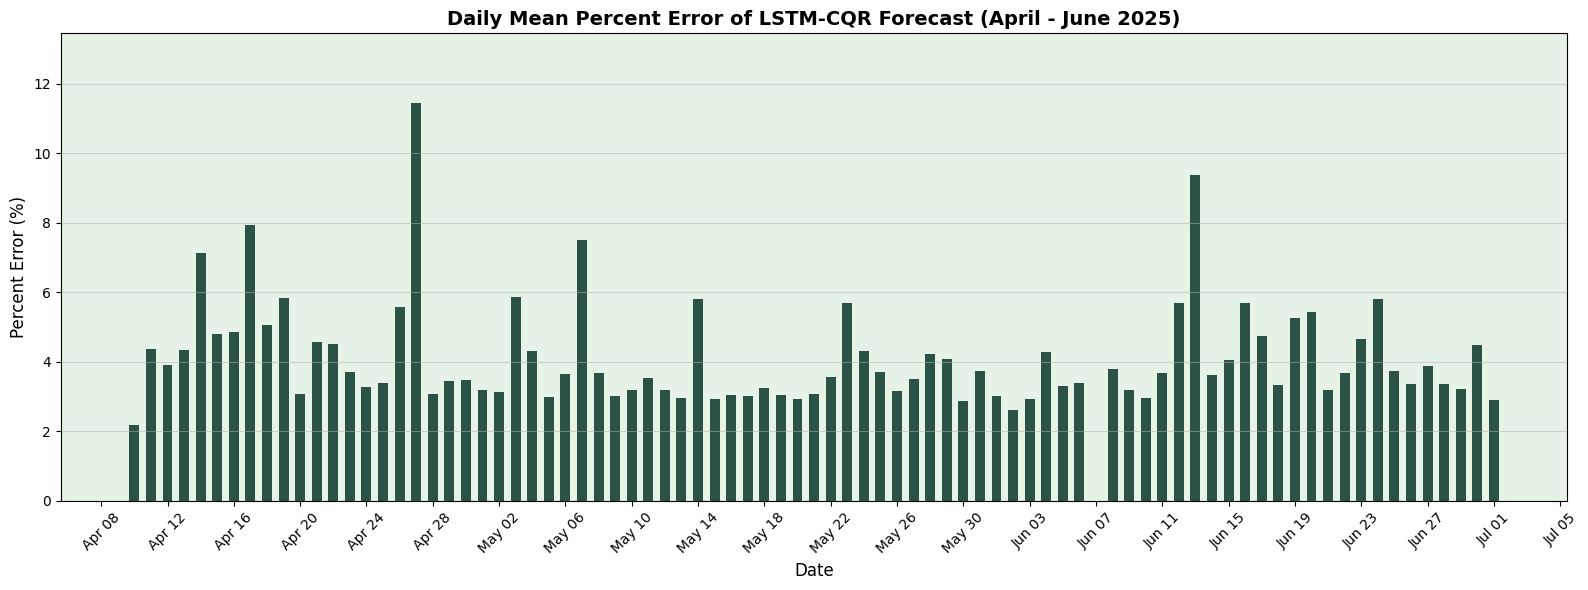

SUCCESS! Fixed percent error bar chart saved.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Daily Percent Error Bar Chart for Agus 1 (Excluding June 7)...")

# 1. Load the Validated CQR Results from Phase 3
df_cqr = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True)

# 1B. THE FIX: Exclude June 7, 2025 to prevent MAPE mathematical singularity
df_cqr = df_cqr[~((df_cqr.index.month == 6) & (df_cqr.index.day == 7))]

# 2. Calculate the Absolute Percent Error for every 15-minute step
# Replacing 0s with NaN to avoid standard division by zero
actuals_safe = df_cqr['Actual_MW'].replace(0, np.nan)
df_cqr['Percent_Error'] = (abs(df_cqr['Actual_MW'] - df_cqr['Point_Prediction_MW']) / actuals_safe) * 100

# 3. Aggregate into Daily Averages
daily_error = df_cqr['Percent_Error'].resample('D').mean()

# Clean up any purely blank days left behind
daily_error = daily_error.dropna()

# 4. Create the Bar Chart Visualization
plt.figure(figsize=(16, 6))

# Plotting the bars
plt.bar(daily_error.index, daily_error.values, color='#2F4F4F', width=0.6)

# Create the subtle green background spanning across the plot area
#plt.axhspan(0, daily_error.max() + 2, facecolor='green', alpha=0.1)

# 5. Professional Academic Formatting
plt.title('Daily Mean Percent Error of LSTM-CQR Forecast (April - June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Percent Error (%)', fontsize=12)

# Format x-axis to show the days neatly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

# Set y-axis limits to start exactly at 0
plt.ylim(0, daily_error.max() + 2)
plt.grid(axis='y', linestyle='-', alpha=0.5)

plt.tight_layout()

# Save and Show
plt.savefig('Agus1_Daily_Percent_Error_wojune7.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Fixed percent error bar chart saved.")

Generating Daily Winkler Penalty Tracker for Agus 1...


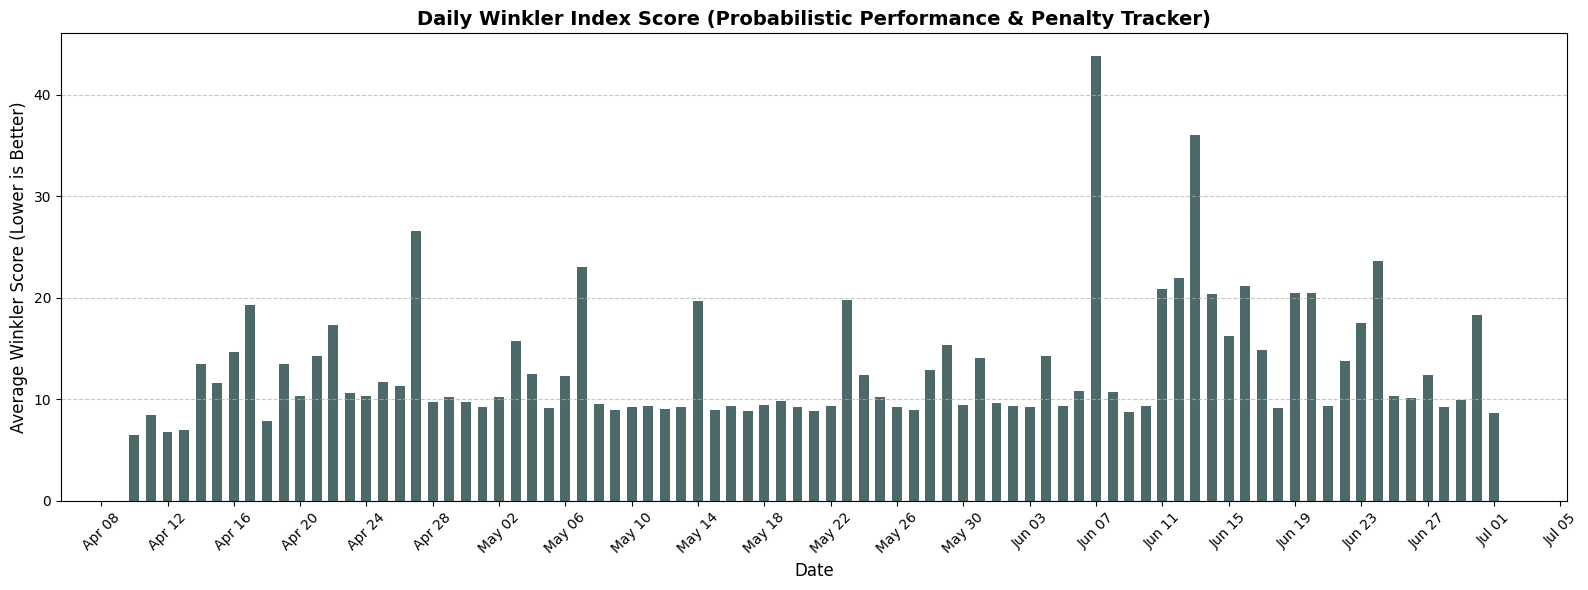

SUCCESS! Daily Winkler plot saved.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Daily Winkler Penalty Tracker for Agus 1...")

# 1. Load the Validated CQR Results
df_cqr = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True)

# Define your significance level
alpha = 0.10  

# 2. Mathematically Calculate the Winkler Score for EVERY 15-min interval
# Base interval width
df_cqr['Interval_Width'] = df_cqr['Physics_Upper_MW'] - df_cqr['Physics_Lower_MW']

# Initialize the Winkler score with the base width
df_cqr['Winkler_Score'] = df_cqr['Interval_Width']

# Apply the Severe Penalty if Actual drops BELOW the Lower Bound
penalty_low_mask = df_cqr['Actual_MW'] < df_cqr['Physics_Lower_MW']
df_cqr.loc[penalty_low_mask, 'Winkler_Score'] += (2 / alpha) * (df_cqr.loc[penalty_low_mask, 'Physics_Lower_MW'] - df_cqr.loc[penalty_low_mask, 'Actual_MW'])

# Apply the Severe Penalty if Actual spikes ABOVE the Upper Bound
penalty_high_mask = df_cqr['Actual_MW'] > df_cqr['Physics_Upper_MW']
df_cqr.loc[penalty_high_mask, 'Winkler_Score'] += (2 / alpha) * (df_cqr.loc[penalty_high_mask, 'Actual_MW'] - df_cqr.loc[penalty_high_mask, 'Physics_Upper_MW'])

# 3. Aggregate into Daily Average Winkler Scores
daily_winkler = df_cqr['Winkler_Score'].resample('D').mean().dropna()

# 4. Create the Visualization
plt.figure(figsize=(16, 6))

# Plotting the bars (Using a deep red/maroon to signify 'Penalties' and 'Uncertainty')
plt.bar(daily_winkler.index, daily_winkler.values, color='#2F4F4F', width=0.6, alpha=0.85)

# 5. Professional Academic Formatting
plt.title('Daily Winkler Index Score (Probabilistic Performance & Penalty Tracker)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Winkler Score (Lower is Better)', fontsize=12)

# Format x-axis to show the days neatly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and Show
plt.savefig('Agus1_Daily_Winkler_Score.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Daily Winkler plot saved.")

Generating Daily RMSE Bar Chart for Agus 1...


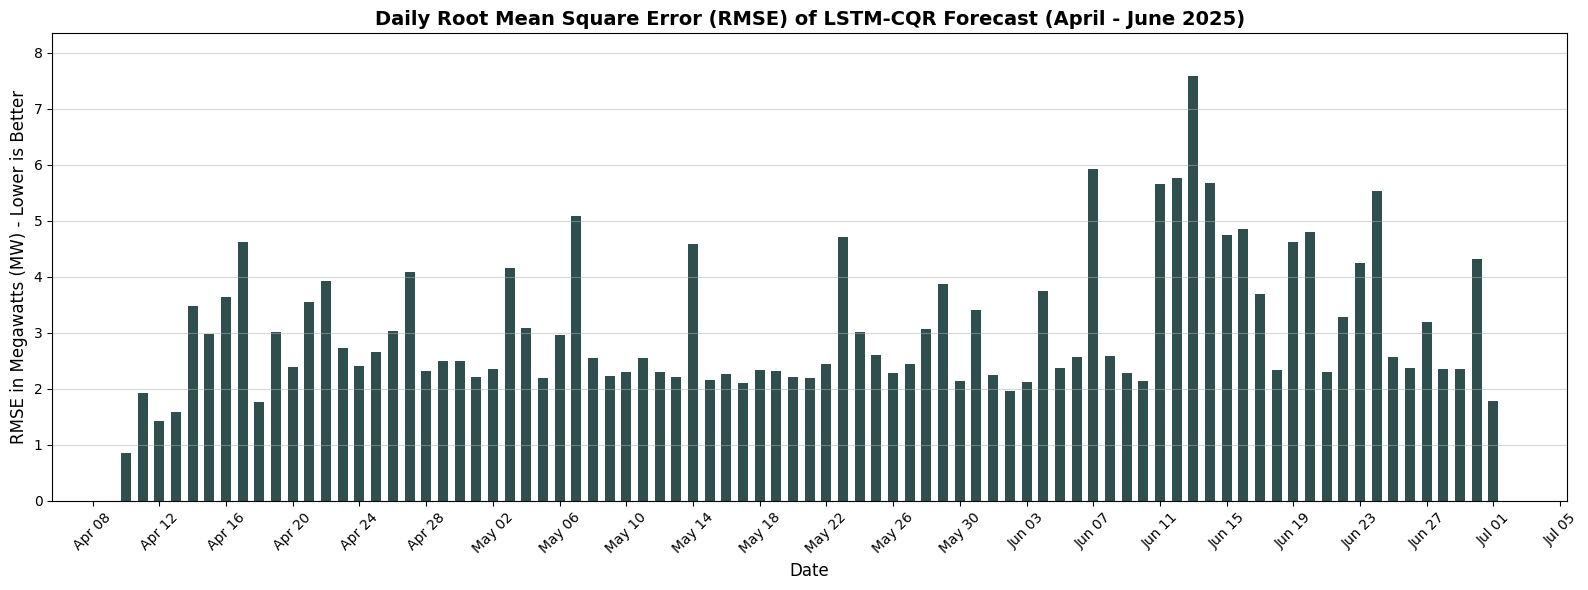

SUCCESS! Daily RMSE bar chart saved.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Generating Daily RMSE Bar Chart for Agus 1...")

# 1. Load the Validated CQR Results from Phase 3
df_cqr = pd.read_csv('Agus1_Validated_CQR_Results.csv', index_col='Time', parse_dates=True, dayfirst=True)

# 1A. Explicitly force the index to be datetime objects
df_cqr.index = pd.to_datetime(df_cqr.index, format='mixed', dayfirst=True)

# Note: We no longer need to exclude June 7! RMSE does not divide by actuals, 
# so 0 MW generation will not cause a mathematical singularity.

# 2. Calculate the Squared Error for every 15-minute step
squared_errors = (df_cqr['Actual_MW'] - df_cqr['Point_Prediction_MW']) ** 2

# 3. Aggregate into Daily Average (MSE), then take the square root for RMSE
daily_mse = squared_errors.resample('D').mean()
daily_rmse = np.sqrt(daily_mse)

# Clean up any purely blank days left behind
daily_rmse = daily_rmse.dropna()

# 4. Create the Bar Chart Visualization
plt.figure(figsize=(16, 6))

# Plotting the bars
plt.bar(daily_rmse.index, daily_rmse.values, color='#2F4F4F', width=0.6)

# 5. Professional Academic Formatting
plt.title('Daily Root Mean Square Error (RMSE) of LSTM-CQR Forecast (April - June 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('RMSE in Megawatts (MW) - Lower is Better', fontsize=12)

# Format x-axis to show the days neatly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=4))
plt.xticks(rotation=45)

# Set y-axis limits to start exactly at 0, scaled slightly above the max bar
plt.ylim(0, daily_rmse.max() * 1.1)
plt.grid(axis='y', linestyle='-', alpha=0.5)

plt.tight_layout()

# Save and Show
plt.savefig('Agus1_Daily_RMSE.png', dpi=300, bbox_inches='tight')
plt.show()

print("SUCCESS! Daily RMSE bar chart saved.")